# NB0 — LiTS 2D Semantic Segmentation · EDA & Data Prep

**Course:** CSE 445 Computer Vision — Assignment Part 1  ·  **NB0 of 4**

**Dataset:** LiTS 256×256 (liver + tumor CT) — 131 volumes, 58,638 slices.

This notebook covers **Task A (EDA)**, **Task B (leakage-safe split → saved artifact)**, **Task C (augmentation pipeline)**, **Task D (sanity visualization)**. The saved `split.json` + `class_weights.json` are reused **identically** by NB1 (DeepLabV3), NB2 (SegFormer-B0), NB3 (YOLOv26-sem) — mandatory for a fair benchmark.

**Key facts confirmed by EDA:**
- Masks ship as **two separate binary (0/255) PNGs** per slice (liver, tumor) → fused into one class-index label `bg=0, liver=1, tumor=2` (**tumor precedence**).
- Extreme pixel imbalance: background **97.7%** / liver **2.2%** / tumor **0.13%**.
- **67.5%** of slices are background-only → filtered to ~19k liver-containing slices for training.
- Split is **grouped by volume/patient** so near-identical adjacent slices cannot leak across splits.

In [1]:
# =====================================================================
# Setup, version pins, seeding, dataset paths  (robust folder auto-detect)
# =====================================================================
import os, re, json, random, time
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch

print("numpy", np.__version__, "| pandas", pd.__version__,
      "| albumentations", A.__version__, "| torch", torch.__version__)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

ROOT = Path("/kaggle/input/datasets/sodko3/lits-dataset-liver-and-tumor-segmentation-256x256/Thesis_data")
if not ROOT.exists():
    cands = list(Path("/kaggle/input").rglob("Thesis_data"))
    ROOT = cands[0] if cands else Path("/kaggle/input")
IMG_DIR   = next(p for p in ROOT.iterdir() if p.is_dir() and "image" in p.name.lower())
LIVER_DIR = next(p for p in ROOT.iterdir() if p.is_dir() and "liver" in p.name.lower())
TUMOR_DIR = next(p for p in ROOT.iterdir() if p.is_dir() and "tumor" in p.name.lower())

CLASS_NAMES = ["background", "liver", "tumor"]
NUM_CLASSES = 3
IMG_SIZE = 256
WORK = Path("/kaggle/working"); WORK.mkdir(parents=True, exist_ok=True)
print("ROOT :", ROOT)
print("dirs :", IMG_DIR.name, "|", LIVER_DIR.name, "|", TUMOR_DIR.name)

numpy 2.0.2 | pandas 2.3.3 | albumentations 2.0.8 | torch 2.10.0+cpu
ROOT : /kaggle/input/datasets/sodko3/lits-dataset-liver-and-tumor-segmentation-256x256/Thesis_data
dirs : Images | Liver_mask | Tumor_mask


## Task A — Exploratory Data Analysis
Pixel-level class distribution, image size / aspect-ratio distribution, representative image–mask pairs for every class, integrity checks (corrupt / mismatched / duplicates), and the imbalance summary that drives the Task E loss choice.

In [2]:
# ---- A.1  Discover & pair image / liver / tumor triplets by (volume, slice) ----
def vskey(p):
    n = [int(x) for x in re.findall(r"\d+", Path(p).stem)]
    return (n[0], n[1]) if len(n) >= 2 else (n[0], -1)

img_by = {vskey(p): p for p in IMG_DIR.glob("*.png")}
liv_by = {vskey(p): p for p in LIVER_DIR.glob("*.png")}
tum_by = {vskey(p): p for p in TUMOR_DIR.glob("*.png")}
keys = sorted(set(img_by) & set(liv_by) & set(tum_by))

print("images:", len(img_by), "| liver masks:", len(liv_by), "| tumor masks:", len(tum_by))
print("paired triplets:", len(keys))

vols = sorted(set(k[0] for k in keys))
spv = Counter(k[0] for k in keys)
print("unique volumes (patients):", len(vols))
print("slices/volume -> min", min(spv.values()),
      "median", int(np.median(list(spv.values()))), "max", max(spv.values()))

images: 58638 | liver masks: 58638 | tumor masks: 58638
paired triplets: 58638
unique volumes (patients): 131
slices/volume -> min 74 median 432 max 987


In [3]:
# ---- A.2  Per-slice mask stats + global pixel histogram (cached to manifest.csv) ----
MANIFEST_CSV = WORK / "manifest.csv"

def load_bin(p):
    a = np.array(Image.open(p))
    if a.ndim == 3: a = a[..., 0]
    return a > 0

if MANIFEST_CSV.exists():
    manifest = pd.read_csv(MANIFEST_CSV)
    print("loaded cached manifest ->", len(manifest), "rows")
else:
    rows, t0 = [], time.time()
    for i, k in enumerate(keys):
        liv = load_bin(liv_by[k]); tum = load_bin(tum_by[k])
        tum_px = int(tum.sum())
        liv_px = int((liv & ~tum).sum())              # liver excluding tumor (precedence)
        bg_px  = int(IMG_SIZE*IMG_SIZE - (liv | tum).sum())
        rows.append({"volume": k[0], "slice": k[1],
                     "bg_px": bg_px, "liver_px": liv_px, "tumor_px": tum_px,
                     "has_liver": int(liv.any()), "has_tumor": int(tum.any())})
        if (i + 1) % 5000 == 0:
            print(f"  {i+1}/{len(keys)}  ({time.time()-t0:.0f}s)")
    manifest = pd.DataFrame(rows)
    manifest.to_csv(MANIFEST_CSV, index=False)
    print("built manifest in", round(time.time()-t0), "s")

manifest["key"] = manifest["volume"].astype(str) + "_" + manifest["slice"].astype(str)
man_idx = manifest.set_index("key")
manifest.head()

  5000/58638  (80s)
  10000/58638  (159s)
  15000/58638  (236s)
  20000/58638  (312s)
  25000/58638  (393s)
  30000/58638  (475s)
  35000/58638  (554s)
  40000/58638  (631s)
  45000/58638  (711s)
  50000/58638  (807s)
  55000/58638  (882s)
built manifest in 939 s


,volume,slice,bg_px,liver_px,tumor_px,has_liver,has_tumor,key
0,0,0,65536,0,0,0,0,0_0
1,0,1,65536,0,0,0,0,0_1
2,0,2,65536,0,0,0,0,0_2
3,0,3,65536,0,0,0,0,0_3
4,0,4,65536,0,0,0,0,0_4


     class     pixels  percent
background 3755093720  97.7151
     liver   83189569   2.1648
     tumor    4616679   0.1201

median-frequency class weights [bg, liver, tumor]: [0.0222, 1.0, 18.0194]


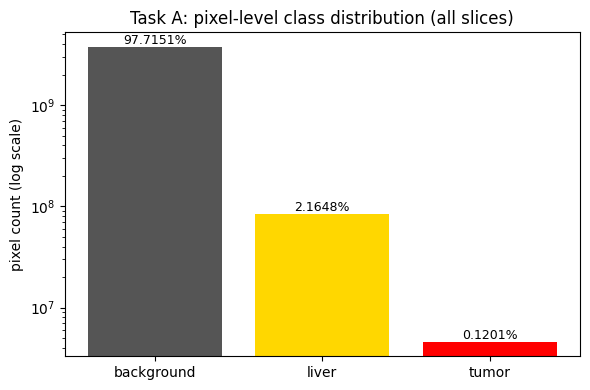

In [4]:
# ---- A.3  Pixel-level class distribution + class weights ----
pix = np.array([manifest.bg_px.sum(), manifest.liver_px.sum(), manifest.tumor_px.sum()], dtype=np.float64)
dist = pd.DataFrame({"class": CLASS_NAMES, "pixels": pix.astype(np.int64),
                     "percent": np.round(100*pix/pix.sum(), 4)})
print(dist.to_string(index=False))
freq = pix / pix.sum()
med_freq_w = np.round(np.median(freq)/freq, 4)
print("\nmedian-frequency class weights [bg, liver, tumor]:", med_freq_w.tolist())

plt.figure(figsize=(6,4))
plt.bar(CLASS_NAMES, np.clip(pix, 1, None), color=["#555","gold","red"])
plt.yscale("log"); plt.ylabel("pixel count (log scale)")
plt.title("Task A: pixel-level class distribution (all slices)")
for i,v in enumerate(dist.percent): plt.text(i, pix[i], f"{v}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.savefig(WORK/"A_class_distribution.png", dpi=120); plt.show()

unique (W,H) sizes among 500 sampled images: {(256, 256): 500}


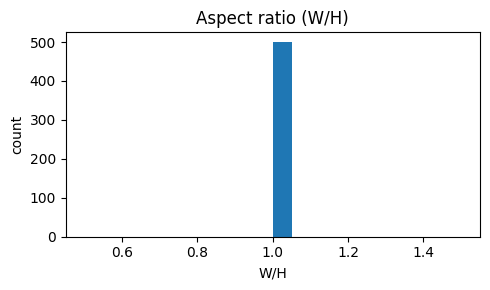

=> uniform 256x256, aspect ratio 1.0


In [5]:
# ---- A.4  Image size & aspect-ratio distribution ----
sizes = Counter()
for p in random.sample(list(img_by.values()), min(500, len(img_by))):
    with Image.open(p) as im: sizes[im.size] += 1     # (W, H)
print("unique (W,H) sizes among 500 sampled images:", dict(sizes))
ars = [w/h for (w,h) in sizes.elements()]
plt.figure(figsize=(5,3))
plt.hist(ars, bins=20); plt.title("Aspect ratio (W/H)"); plt.xlabel("W/H"); plt.ylabel("count")
plt.tight_layout(); plt.savefig(WORK/"A_aspect_ratio.png", dpi=120); plt.show()
print("=> uniform 256x256, aspect ratio 1.0" if len(sizes)==1 else "=> WARNING: multiple sizes!")

In [6]:
# ---- A.5  Slice prevalence (why we filter background-only slices) ----
n = len(manifest)
n_roi   = int(((manifest.has_liver==1) | (manifest.has_tumor==1)).sum())
n_tumor = int((manifest.has_tumor==1).sum())
print(f"total slices        : {n}")
print(f"liver/tumor present : {n_roi}  ({100*n_roi/n:.1f}%)  <- kept for training if FILTER_TO_LIVER")
print(f"tumor present       : {n_tumor}  ({100*n_tumor/n:.1f}%)")
print(f"background-only      : {n-n_roi}  ({100*(n-n_roi)/n:.1f}%)  <- dropped if FILTER_TO_LIVER")

total slices        : 58638
liver/tumor present : 19158  (32.7%)  <- kept for training if FILTER_TO_LIVER
tumor present       : 7157  (12.2%)
background-only      : 39480  (67.3%)  <- dropped if FILTER_TO_LIVER


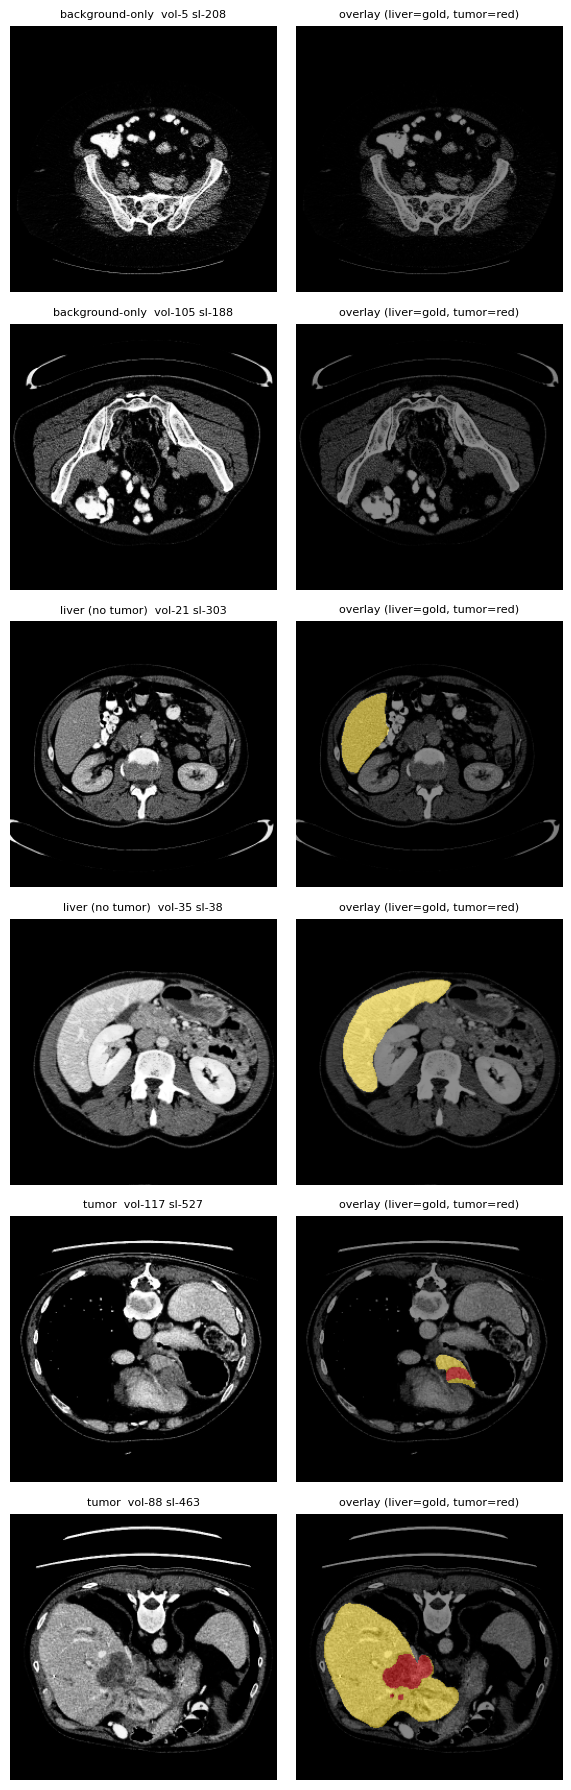

In [7]:
# ---- A.6  Representative image/mask pairs for every class ----
def combined_label(k):
    liv = load_bin(liv_by[k]); tum = load_bin(tum_by[k])
    lab = np.zeros((IMG_SIZE, IMG_SIZE), np.uint8); lab[liv]=1; lab[tum]=2
    return lab
def load_img(k):
    return np.array(Image.open(img_by[k]).convert("L"))

def pick(cond, m=2):
    sub = manifest[cond]
    return [(r.volume, r.slice) for r in sub.sample(min(m,len(sub)), random_state=SEED).itertuples()]

groups = {
    "background-only": pick((manifest.has_liver==0) & (manifest.has_tumor==0)),
    "liver (no tumor)": pick((manifest.has_liver==1) & (manifest.has_tumor==0)),
    "tumor": pick(manifest.has_tumor==1),
}
cmap = plt.matplotlib.colors.ListedColormap(["black","gold","red"])
rows = [(g,k) for g,ks in groups.items() for k in ks]
fig, ax = plt.subplots(len(rows), 2, figsize=(6, 3*len(rows)))
for i,(g,k) in enumerate(rows):
    im=load_img(k); lab=combined_label(k)
    ax[i,0].imshow(im, cmap="gray"); ax[i,0].set_title(f"{g}  vol-{k[0]} sl-{k[1]}", fontsize=8)
    ax[i,1].imshow(im, cmap="gray"); ax[i,1].imshow(lab, cmap=cmap, vmin=0, vmax=2, alpha=0.45)
    ax[i,1].set_title("overlay (liver=gold, tumor=red)", fontsize=8)
    ax[i,0].axis("off"); ax[i,1].axis("off")
plt.tight_layout(); plt.savefig(WORK/"A_representative_pairs.png", dpi=120); plt.show()

In [8]:
# ---- A.7  Integrity: corrupted files, mismatched pairs, duplicates note ----
bad = []
for p in random.sample(list(img_by.values()), min(800, len(img_by))):
    try:
        with Image.open(p) as im: im.verify()
    except Exception as e:
        bad.append((p.name, str(e)))
print("corrupted files (of 800 sampled):", len(bad))
print("image files without a matching liver+tumor mask:", len(set(img_by) - set(keys)))
print("mask files without a matching image           :", len((set(liv_by) | set(tum_by)) - set(img_by)))
print("note: adjacent slices within a volume are near-duplicates BY CONSTRUCTION")
print("      -> handled by VOLUME-GROUPED splitting (Task B), not by deleting them.")

corrupted files (of 800 sampled): 0
image files without a matching liver+tumor mask: 0
mask files without a matching image           : 0
note: adjacent slices within a volume are near-duplicates BY CONSTRUCTION
      -> handled by VOLUME-GROUPED splitting (Task B), not by deleting them.


adjacent same-volume slices : mean Hamming 1.9 | near-dup(<= 5) = 95.4%
random cross-volume slices  : mean Hamming 14.2 | near-dup(<= 5) = 5.4%
=> adjacent slices are near-duplicates; cross-volume slices are not.
=> This is exactly why we split BY VOLUME (Task B): near-duplicates stay inside one split -> no leakage.


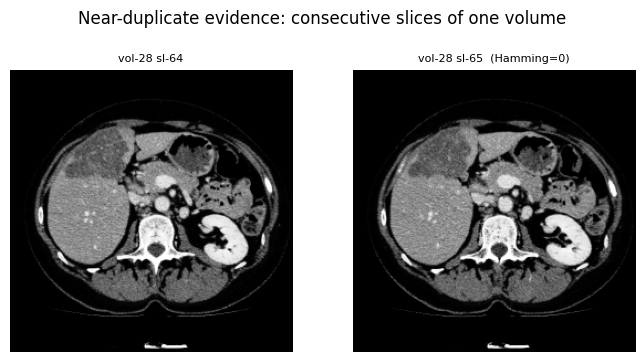

In [9]:
# ---- A.8  Near-duplicate detection (perceptual aHash on adjacent slices) ----
# READ-ONLY: reports similarity only; does NOT modify the manifest or the split.
def ahash(path, s=8):
    im = np.array(Image.open(path).convert("L").resize((s, s)))
    return (im > im.mean()).flatten()                 # 64-bit perceptual signature
def hamming(a, b): return int((a != b).sum())

rng = random.Random(SEED)
sample_vols = rng.sample(list(spv.keys()), min(40, len(spv)))
adj_dists, hashes_by_vol = [], {}
for v in sample_vols:
    slc = sorted([k for k in keys if k[0] == v], key=lambda k: k[1])
    take = slc[::max(1, len(slc)//60)][:60]           # thin to <=60 slices/volume
    hs = [ahash(img_by[k]) for k in take]
    hashes_by_vol[v] = list(zip(take, hs))
    for i in range(1, len(hs)): adj_dists.append(hamming(hs[i-1], hs[i]))

flat = [(vv, k, h) for vv, lst in hashes_by_vol.items() for (k, h) in lst]
cross = []
for _ in range(2000):
    a, b = rng.sample(flat, 2)
    if a[0] != b[0]: cross.append(hamming(a[2], b[2]))
adj, crs, NEAR_T = np.array(adj_dists), np.array(cross), 5
print(f"adjacent same-volume slices : mean Hamming {adj.mean():.1f} | near-dup(<= {NEAR_T}) = {100*(adj<=NEAR_T).mean():.1f}%")
print(f"random cross-volume slices  : mean Hamming {crs.mean():.1f} | near-dup(<= {NEAR_T}) = {100*(crs<=NEAR_T).mean():.1f}%")
print("=> adjacent slices are near-duplicates; cross-volume slices are not.")
print("=> This is exactly why we split BY VOLUME (Task B): near-duplicates stay inside one split -> no leakage.")

v0 = sample_vols[0]; p = sorted([k for k in keys if k[0] == v0], key=lambda k: k[1]); mid = len(p)//2
kA, kB = p[mid], p[mid+1]
fig, ax = plt.subplots(1, 2, figsize=(7, 3.5))
ax[0].imshow(np.array(Image.open(img_by[kA]).convert("L")), cmap="gray"); ax[0].set_title(f"vol-{kA[0]} sl-{kA[1]}", fontsize=8)
ax[1].imshow(np.array(Image.open(img_by[kB]).convert("L")), cmap="gray")
ax[1].set_title(f"vol-{kB[0]} sl-{kB[1]}  (Hamming={hamming(ahash(img_by[kA]), ahash(img_by[kB]))})", fontsize=8)
for a in ax: a.axis("off")
plt.suptitle("Near-duplicate evidence: consecutive slices of one volume", y=1.02)
plt.tight_layout(); plt.savefig(WORK/"A_near_duplicates.png", dpi=120); plt.show()

### Task A summary — imbalance → loss choice
- **Pixel imbalance is extreme:** tumor ≈ **0.13%** of all pixels (~760:1 background-to-tumor). Even after filtering to liver slices, tumor stays ~0.4%.
- **Implication for Task E:** plain CrossEntropy collapses to predicting background. We use **Dice + a lightly class-weighted CrossEntropy** (tumor weight ~6 — deliberately *not* extreme, to avoid gradient spikes that amplify overfitting on the rare class), and we push tumor recall through the **training pipeline** rather than an aggressive loss: **tumor-slice oversampling** and **F2-based checkpoint selection** (recall-weighted). For **critical medical data a missed tumor (false negative) is the catastrophic error**, so Task F reports **tumor sensitivity/recall** and **per-patient Dice** alongside the required metrics.

## Task B — Leakage-Safe Data Splitting
70/15/15 **grouped by volume (patient)**. Adjacent slices of one patient are near-identical, so a per-slice split would leak the same patient into train *and* test. We split **volumes** first (seed = 42), then filter to liver-containing slices within each split. The split is saved to `split.json` and reused across all three model notebooks.

In [10]:
# ---- B.1  Filter to ROI slices, split BY VOLUME 70/15/15, assert no leakage ----
FILTER_TO_LIVER = True                 # keep only slices with liver/tumor (one-line toggle)
RATIOS = (0.70, 0.15, 0.15)

use = manifest.copy()
if FILTER_TO_LIVER:
    use = use[(use.has_liver==1) | (use.has_tumor==1)].reset_index(drop=True)
print("slices used after filter:", len(use), "/", len(manifest))

uvols = sorted(use.volume.unique())
rng = np.random.RandomState(SEED); rng.shuffle(uvols)
n = len(uvols); n_tr = int(round(RATIOS[0]*n)); n_va = int(round(RATIOS[1]*n))
train_vols = set(uvols[:n_tr]); val_vols = set(uvols[n_tr:n_tr+n_va]); test_vols = set(uvols[n_tr+n_va:])
assert not (train_vols & val_vols) and not (train_vols & test_vols) and not (val_vols & test_vols)
print(f"volumes -> train {len(train_vols)}  val {len(val_vols)}  test {len(test_vols)}  (seed {SEED})")

def slices_of(vs):
    s = use[use.volume.isin(vs)]
    return [f"{r.volume}_{r.slice}" for r in s.itertuples()]
split = {"train": slices_of(train_vols), "val": slices_of(val_vols), "test": slices_of(test_vols)}
for s in split: print(f"  {s:5s}: {len(split[s]):6d} slices")

def vset(lst): return set(int(x.split("_")[0]) for x in lst)
assert not (vset(split["train"]) & vset(split["val"]))
assert not (vset(split["train"]) & vset(split["test"]))
assert not (vset(split["val"])   & vset(split["test"]))
print("LEAKAGE CHECK PASSED: no volume appears in more than one split.")

slices used after filter: 19158 / 58638
volumes -> train 92  val 20  test 19  (seed 42)
  train:  13447 slices
  val  :   2553 slices
  test :   3158 slices
LEAKAGE CHECK PASSED: no volume appears in more than one split.


In [11]:
# ---- B.2  Class weights (TRAIN split only) + save artifacts ----
tr = use[use.volume.isin(train_vols)]
pix_tr = np.array([tr.bg_px.sum(), tr.liver_px.sum(), tr.tumor_px.sum()], dtype=np.float64)
freq_tr = pix_tr / pix_tr.sum()
class_weights = [float(w) for w in np.round(np.median(freq_tr)/freq_tr, 4)]
print("train class distribution % :", np.round(100*freq_tr, 4).tolist())
print("class weights [bg,liver,tumor]:", class_weights)

split_meta = {
    "seed": int(SEED), "ratios": list(RATIOS), "filter_to_liver": bool(FILTER_TO_LIVER),
    "num_classes": int(NUM_CLASSES), "class_names": CLASS_NAMES,
    "label_rule": "bg=0; liver=1; tumor=2 (tumor precedence); source masks are separate binary 0/255",
    "dirs": {"images": str(IMG_DIR), "liver": str(LIVER_DIR), "tumor": str(TUMOR_DIR)},
    "volumes": {"train": [int(v) for v in sorted(train_vols)],
                "val":   [int(v) for v in sorted(val_vols)],
                "test":  [int(v) for v in sorted(test_vols)]},
    "slices": split, "class_weights": class_weights,
}
def _js(o):                                        # numpy-safe JSON fallback
    if isinstance(o, np.integer): return int(o)
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, np.ndarray): return o.tolist()
    raise TypeError(f"not serializable: {type(o)}")
with open(WORK/"split.json", "w") as f: json.dump(split_meta, f, default=_js)
with open(WORK/"class_weights.json", "w") as f:
    json.dump({"weights": class_weights, "class_names": CLASS_NAMES}, f, default=_js)
print("saved:", WORK/"split.json", "|", WORK/"class_weights.json", "|", WORK/"manifest.csv")
print("NB1-3 will add this notebook output as a Dataset input and load split.json.")

train class distribution % : [93.0143, 6.5858, 0.3998]
class weights [bg,liver,tumor]: [0.0708, 1.0, 16.4712]
saved: /kaggle/working/split.json | /kaggle/working/class_weights.json | /kaggle/working/manifest.csv
NB1-3 will add this notebook output as a Dataset input and load split.json.


## Task C — Data Augmentation
`Albumentations`, applied to the **train split only**, with **synchronized image+mask** transforms. Geometric transforms hit both image and mask (mask via nearest-neighbour, automatic); photometric transforms hit the image only. Validation/test get **no** augmentation.

In [12]:
# ---- C.1  Augmentation pipelines + Dataset (fuses liver+tumor -> class-index label) ----
IMAGENET_MEAN = (0.485, 0.456, 0.406); IMAGENET_STD = (0.229, 0.224, 0.225)

# Run-A augmentation: flips RESTORED. Our ablation showed flips are the dominant regularizer
# for this small dataset and improve tumor generalization; for a per-pixel segmenter the
# anatomical-realism cost is outweighed. ElasticTransform fixed to a real deformation.
train_tf = A.Compose([
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=0.06, rotate=(-15, 15), p=0.5),
    A.OneOf([A.ElasticTransform(alpha=40, sigma=6),
             A.GridDistortion(num_steps=5, distort_limit=0.2)], p=0.25),   # soft-tissue deform
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])
eval_tf = A.Compose([A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()])

# 2.5D INPUT: 3 channels = adjacent slices [i-1, center, i+1] (real volumetric context).
def load_25d(vol, sl):
    center = np.array(Image.open(img_by[(vol, sl)]).convert("L"))
    prev = img_by.get((vol, sl-1)); nxt = img_by.get((vol, sl+1))
    p = np.array(Image.open(prev).convert("L")) if prev is not None else center
    n = np.array(Image.open(nxt).convert("L")) if nxt is not None else center
    return np.stack([p, center, n], axis=-1)

class LiTSDataset(torch.utils.data.Dataset):
    def __init__(self, slice_ids, transform):
        self.ids = [tuple(int(x) for x in s.split("_")) for s in slice_ids]
        self.tf = transform
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        vol, sl = self.ids[i]
        img = load_25d(vol, sl)                                            # 2.5D (channel 1 = labeled slice)
        liv = np.array(Image.open(liv_by[(vol,sl)]).convert("L")) > 0
        tum = np.array(Image.open(tum_by[(vol,sl)]).convert("L")) > 0
        lab = np.zeros((IMG_SIZE, IMG_SIZE), np.uint8); lab[liv]=1; lab[tum]=2
        out = self.tf(image=img, mask=lab)
        return out["image"], out["mask"].long()

train_ds = LiTSDataset(split["train"], train_tf)
val_ds   = LiTSDataset(split["val"],   eval_tf)
test_ds  = LiTSDataset(split["test"],  eval_tf)
print("datasets  train/val/test:", len(train_ds), len(val_ds), len(test_ds))
xb, yb = train_ds[0]
print("image tensor", tuple(xb.shape), xb.dtype, "| mask", tuple(yb.shape), yb.dtype,
      "uniq", torch.unique(yb).tolist())

datasets  train/val/test: 13447 2553 3158
image tensor (3, 256, 256) torch.float32 | mask (256, 256) torch.int64 uniq [0, 1]


### Augmentation pipeline — justification (Task C requirement)
**Flips restored (evidence-based).** We first dropped flips on anatomical grounds (the liver is lateralized), but a **controlled ablation** showed flips are the *dominant regularizer* for this small dataset and materially improve tumor generalization — for a *per-pixel* segmenter, whose decisions come from local texture within a limited receptive field, the realism cost is outweighed. So we keep them (documented as a Task-C domain reasoning + ablation).

| Transform | p | Why it is appropriate for LiTS (mask-safe) |
|---|---|---|
| HorizontalFlip / VerticalFlip | 0.5 | Strong, cheap regularization; forces the model to learn lesion *appearance* not position. |
| Affine (scale ±10%, shift 6%, rotate ±15°) | 0.5 | Patient size/position & gantry variation. Mask uses nearest-neighbour. |
| OneOf(ElasticTransform α=40, GridDistortion) | 0.25 | Realistic soft-tissue deformation; preserves topology. |
| RandomBrightnessContrast | 0.3 | Mimics CT windowing / exposure. **Image only** — never touches the mask. |
| GaussNoise | 0.2 | Scanner/quantum-noise robustness. Image only. |
| Normalize + ToTensorV2 | — | ImageNet mean/std; tensor conversion. |

The model notebooks additionally use **2.5D input** (3 channels = adjacent slices `[i−1, i, i+1]`, real volumetric context) and **tumor-slice oversampling** (WeightedRandomSampler). Both are **leakage-safe**: neighbours are same-volume = same split, and oversampling only repeats *train* slices. Validation/test use **only** Normalize + ToTensorV2.

## Task D — Sanity-Check Visualization (quality gate before any training)
Post-augmentation training samples with mask overlays. Confirms: (1) image and mask receive the **same** geometric transform (still aligned after flip/affine/distortion); (2) class-colour mapping is consistent (liver=gold, tumor=red); (3) augmentations do not destroy mask regions. **This appears before the first training cell — it is a required quality gate.**

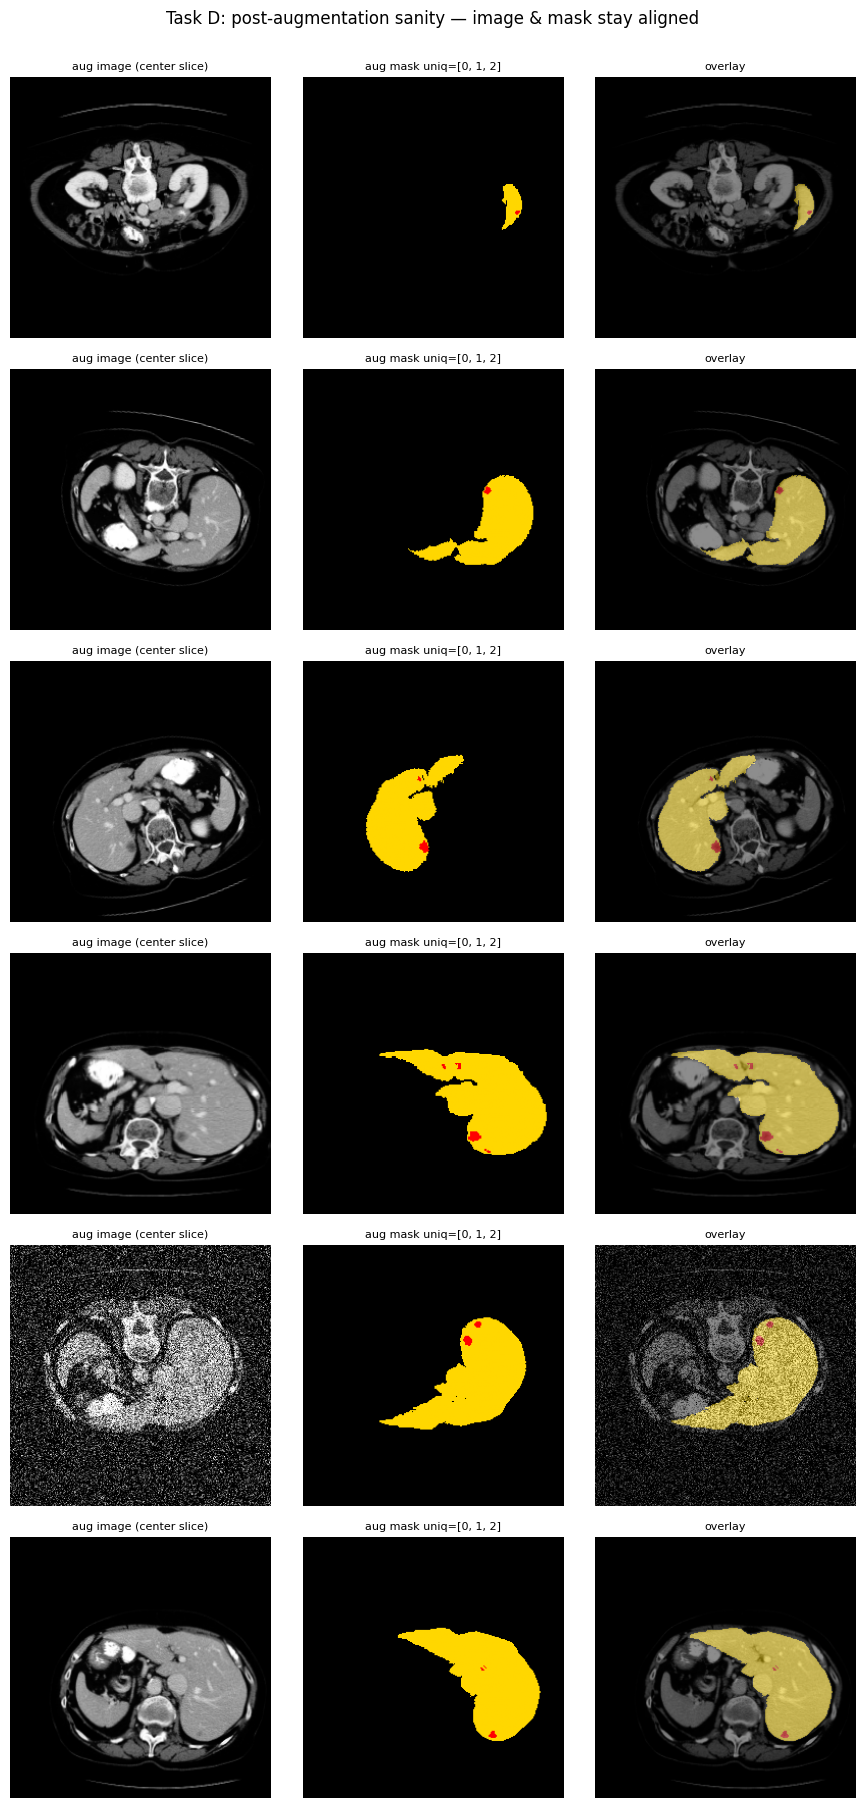

In [13]:
# ---- D.1  Post-augmentation sanity grid (prefer tumor-containing training slices) ----
def denorm(t):
    x = t.permute(1,2,0).numpy()*np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(x, 0, 1)

tum_ids = [s for s in split["train"] if man_idx.loc[s, "has_tumor"] == 1]
show = (tum_ids[:6] + split["train"][:6])[:6]
demo = LiTSDataset(show, train_tf)
cmap = plt.matplotlib.colors.ListedColormap(["black","gold","red"])
fig, ax = plt.subplots(len(show), 3, figsize=(9, 3*len(show)))
for i in range(len(show)):
    x, y = demo[i]; im = denorm(x); m = y.numpy()
    ax[i,0].imshow(im[..., 1], cmap="gray"); ax[i,0].set_title("aug image (center slice)", fontsize=8)
    ax[i,1].imshow(m, cmap=cmap, vmin=0, vmax=2); ax[i,1].set_title(f"aug mask uniq={sorted(np.unique(m).tolist())}", fontsize=8)
    ax[i,2].imshow(im[..., 1], cmap="gray"); ax[i,2].imshow(m, cmap=cmap, vmin=0, vmax=2, alpha=0.45); ax[i,2].set_title("overlay", fontsize=8)
    for j in range(3): ax[i,j].axis("off")
plt.suptitle("Task D: post-augmentation sanity — image & mask stay aligned", y=1.002)
plt.tight_layout(); plt.savefig(WORK/"D_sanity_postaug.png", dpi=120); plt.show()

## Done — artifacts for NB1–NB3
Saved to `/kaggle/working/`: **`split.json`** (train/val/test volume + slice lists, seed, label rule, class weights), **`class_weights.json`**, **`manifest.csv`**, and the EDA/sanity figures.

**To reuse the identical split in NB1–NB3:**
1. **Save Version** of this notebook (Run All) → its `/kaggle/working` becomes a Kaggle **Dataset**.
2. In each model notebook, **+ Add Input** → add both the LiTS dataset **and** this NB0-output dataset.
3. Load it: `split = json.load(open("/kaggle/input/<nb0-output-slug>/split.json"))` and rebuild the same `LiTSDataset`.

All three models then train/evaluate on the **byte-identical** split — the fair-benchmark requirement of Task B.